# 多层感知机的从零开始实现

我们已经在 [4.1节](./04.01_mlp.ipynb)中描述了多层感知机（MLP），现在让我们尝试自己实现一个多层感知机。我们继续使用 Fashion-MNIST 图像分类数据集。

## 环境配置

In [ ]:
%pip install pypto==0.2.0 torch torch_npu numpy

In [ ]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Cannot create tensor with internal format")
import pypto
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch_npu
import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

## 数据准备

使用 Fashion-MNIST 数据集（28×28 灰度图，10 个服装类别），与第 3 章相同。


In [3]:
batch_size = 256

# 1. 定义数据预处理：将图片转换为张量，并归一化到 [0, 1] 区间
trans = transforms.ToTensor()

# 2. 下载并加载训练集和测试集
mnist_train = datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
mnist_test = datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)

# 3. 创建数据迭代器
train_iter = DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0)
test_iter = DataLoader(mnist_test, batch_size, shuffle=False, num_workers=0)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
import torch
from torch import nn
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
    </pre>
  </div>
</details>

---


## 初始化模型参数

回想一下，Fashion-MNIST中的每个图像由$28 \times 28 = 784$个灰度像素值组成。所有图像共分为10个类别。忽略像素之间的空间结构，我们可以将每个图像视为具有784个输入特征和10个类的简单分类数据集。首先，我们将**实现一个具有单隐藏层的多层感知机，它包含256个隐藏单元**。注意，我们可以将这两个变量都视为超参数。通常，我们选择2的若干次幂作为层的宽度。因为内存在硬件中的分配和寻址方式，这么做往往可以在计算上更高效。我们用几个张量来表示我们的参数。注意，对于每一层我们都要记录一个权重矩阵和一个偏置向量。跟以前一样，我们要为损失关于这些参数的梯度分配内存。


In [4]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

## 激活函数

为了确保我们对模型的细节了如指掌，我们将**实现ReLU激活函数**，而不是直接调用内置的`relu`函数。

我们将为 ReLU 编写 pypto 前向/反向 kernel，使其运行在昇腾 NPU 上。pypto 的 tile 切分机制将大矩阵分块并行计算，充分利用 NPU 的多计算核心。

In [5]:
# 前向：y = max(x, 0)
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def relu_fwd_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    y.move(pypto.maximum(x, 0.0))

# 反向：grad_in = grad_out * (y > 0) 
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def relu_bwd_kernel(
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    grad_in: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    grad_in.move(pypto.where(y > 0.0, grad_out, 0.0))

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><code>pypto.set_vec_tile_shapes(128, 128)</code> 将张量按 128×128 的块（tile）并行切分——NPU 多核心同时对不同 tile 执行计算。</li>
      <li style="margin: 0 0 8px 0;">前向 kernel 用 <code>pypto.maximum(x, 0.0)</code> 实现 <code>max(x,0)</code>；反向 kernel 用 <code>pypto.where(y &gt; 0, grad_out, 0.0)</code> 实现“正数传梯度、负数截断”的 ReLU 反向逻辑。</li>
    </ul>
  </div>
</details>
<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)
    </pre>
  </div>
</details>

## 模型

因为我们忽略了空间结构，所以我们使用`reshape`将每个二维图像转换为一个长度为`num_inputs`的向量。只需几行代码就可以**实现我们的模型**。

为了在 NPU 上端到端训练，需要将矩阵乘、偏置加和 ReLU 都用 pypto 实现。三个算子的前向与反向的数学公式如下：

$$
\begin{array}{c|c|c|c}
 & \text{Matmul} & \text{BiasAdd} & \text{ReLU} \\ \hline
\text{前向} & \mathbf{C} = \mathbf{A}\mathbf{B} & \mathbf{Y} = \mathbf{X} + \mathbf{b} & y = \max(x, 0) \\ \hline
\text{反向} & \dfrac{\partial L}{\partial \mathbf{A}} = \dfrac{\partial L}{\partial \mathbf{C}} \mathbf{B}^\top,\; \dfrac{\partial L}{\partial \mathbf{B}} = \mathbf{A}^\top \dfrac{\partial L}{\partial \mathbf{C}} & \dfrac{\partial L}{\partial \mathbf{b}} = \sum_i \dfrac{\partial L}{\partial \mathbf{Y}_{i,:}} & \dfrac{\partial y}{\partial x} = \mathbf{1}_{y>0}
\end{array}
$$

下面编写 matmul 和 bias_add 的 pypto kernel（ReLU kernel 已在上一节实现），并用工厂模式封装为 <code>torch.autograd.Function</code> 子类。


In [6]:
# 前向：C = A @ B
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def matmul_fwd_kernel(
    a: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
    c: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([16, 16], [16, 16], [16, 16])
    c.move(pypto.matmul(a, b, pypto.DT_FP32))

# 反向：grad_a = grad_c @ b.T, grad_b = a.T @ grad_c
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def matmul_bwd_kernel(
    a: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
    grad_c: pypto.Tensor([], pypto.DT_FP32),
    grad_a: pypto.Tensor([], pypto.DT_FP32),
    grad_b: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_cube_tile_shapes([16, 16], [16, 16], [16, 16])
    grad_a.move(pypto.matmul(grad_c, b, pypto.DT_FP32, b_trans=True))
    grad_b.move(pypto.matmul(a, grad_c, pypto.DT_FP32, a_trans=True))

# 前向：Y = X + b（逐行广播）
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def bias_add_fwd_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    y.move(x + b)

# 反向：grad_b = sum(grad_y, dim=0)
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def bias_add_bwd_kernel(
    grad_y: pypto.Tensor([], pypto.DT_FP32),
    grad_b: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    grad_b.move(pypto.sum(grad_y, 0, True))

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <p><b><code>a_trans</code> 和 <code>b_trans</code> 参数</b>：<code>pypto.matmul(a, b, dtype, a_trans=False, b_trans=False)</code> 支持在矩阵乘时<b>随路完成转置</b>，即矩阵乘和转置在一个 Kernel 调用内完成，避免额外调用 <code>pypto.transpose()</code>。</p>
    <p>前向 <code>C = A @ B</code> 无需转置，两个参数使用默认值 <code>False</code>。</p>
    <p>反向需要计算转置后的乘法：</p>
    <ul style="margin: 0 0 8px 20px;">
      <li style="margin: 0 0 4px 0;"><code>grad_A = grad_C @ B<sup>T</sup></code> → <code>b_trans=True</code>，随路转置 <code>b</code></li>
      <li style="margin: 0 0 4px 0;"><code>grad_B = A<sup>T</sup> @ grad_C</code> → <code>a_trans=True</code>，随路转置 <code>a</code></li>
    </ul>
    <p>随路转置省去了单独 <code>transpose()</code> 的调用及中间张量开销。</p>
  </div>
</details>

### 将 pypto Kernel 封装为 torch 算子

上一节（[4.1 节](./04.01_mlp.ipynb)）我们用工厂模式封装了激活函数 Kernel；本节我们对 matmul、bias_add 也做同样的封装。**工厂模式**把前向/反向 Kernel 包装成 `torch.autograd.Function` 子类，之后就能像普通 PyTorch 算子一样用 `.apply()` 调用，自动接入梯度计算。

下面逐个实现 matmul、bias_add、ReLU 三个算子的工厂函数，关于工厂模式、`ctx`（上下文）和 `.apply()` 的详细说明见下方代码说明折叠区。

In [7]:
# matmul 工厂
def make_pypto_matmul(fwd_kernel, bwd_kernel):
    class PyPTOMatmulImpl(torch.autograd.Function):
        @staticmethod
        def forward(ctx, a, b):
            ctx.save_for_backward(a, b)
            c = torch.empty(a.shape[0], b.shape[1], device=a.device, dtype=a.dtype)
            fwd_kernel(
                a, b, c
            )
            return c

        @staticmethod
        def backward(ctx, grad_c):
            a, b = ctx.saved_tensors
            grad_a = torch.empty_like(a)
            grad_b = torch.empty_like(b)
            bwd_kernel(
                a.contiguous(), b.contiguous(),
                grad_c.contiguous(),
                grad_a, grad_b,
            )
            return grad_a, grad_b

    return PyPTOMatmulImpl

PyPTOMatmul = make_pypto_matmul(matmul_fwd_kernel, matmul_bwd_kernel)

In [8]:
# bias_add 工厂 
def make_pypto_bias_add(fwd_kernel, bwd_kernel):
    class PyPTOBiasAddImpl(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x, b):
            ctx.save_for_backward(x)
            y = torch.empty_like(x)
            fwd_kernel(
                x, b, y
            )
            return y

        @staticmethod
        def backward(ctx, grad_y):
            grad_x = grad_y
            grad_b = torch.empty(1, grad_y.shape[1], device=grad_y.device, dtype=grad_y.dtype)
            bwd_kernel(
                grad_y.contiguous(), grad_b
            )
            return grad_x, grad_b.squeeze(0)

    return PyPTOBiasAddImpl

PyPTOBiasAdd = make_pypto_bias_add(bias_add_fwd_kernel, bias_add_bwd_kernel)

In [9]:
# relu 工厂
def make_pypto_relu(fwd_kernel, bwd_kernel):
    class PyPTOReLUImpl(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            y = torch.empty_like(x)
            fwd_kernel(x, y)
            ctx.save_for_backward(y)
            return y

        @staticmethod
        def backward(ctx, grad_out):
            (y,) = ctx.saved_tensors
            grad_in = torch.empty_like(y)
            bwd_kernel(
                y, grad_out,
                grad_in,
            )
            return grad_in

    return PyPTOReLUImpl

PyPTOReLU = make_pypto_relu(relu_fwd_kernel, relu_bwd_kernel)

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <p><b>工厂模式</b>：<code>make_pypto_matmul / make_pypto_bias_add / make_pypto_relu</code> 是<b>工厂函数</b>——接收前向/反向 Kernel 作为参数，返回一个继承 <code>torch.autograd.Function</code> 的类。这样做是为了解决依赖顺序问题：pypto Kernel 必须先用 <code>@pypto.frontend.jit</code> 定义好，才能被 PyTorch 的自动微分类引用。</p>
    <p><b><code>ctx</code>（上下文）</b>：<code>ctx</code> 是 PyTorch 在 forward / backward 之间传递数据的通道。在前向阶段通过 <code>ctx.save_for_backward</code> 保存前向中间结果，反向阶段通过 <code>ctx.saved_tensors</code> 取回——没有 ctx，反向就拿不到前向的中间结果。</p>
    <p><b><code>.apply()</code></b>：PyTorch 的调用入口，自动触发 <code>forward</code> / <code>backward</code>。用户只需写 <code>PyPTOMatmul.apply(X, W)</code>，PyTorch 自动管好计算图构建和梯度传播。</p>
    <p><b>各算子实现要点</b>：</p>
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;">matmul 使用 <code>pypto.set_cube_tile_shapes</code> 配合 Cube 指令，以 16×16 子矩阵块加速矩阵乘法。</li>
      <li style="margin: 0 0 8px 0;">bias_add 使用 <code>pypto.set_vec_tile_shapes</code>，前向执行逐行广播加法，反向对 <code>grad_y</code> 沿 batch 维求和得到 <code>grad_b</code>。</li>
      <li style="margin: 0 0 8px 0;">ReLU 使用 <code>pypto.maximum(x, 0.0)</code> 前向、<code>pypto.where(y &gt; 0, grad_out, 0.0)</code> 反向。</li>
    </ul>
  </div>
</details>

### 用 NPU 算子搭模型

有了上面三个工厂创建的算子，我们可以直接调用它们来定义 MLP 的前向传播：

```
X → flatten → Matmul(W1) → Bias(b1) → ReLU → Matmul(W2) → Bias(b2) → logits
```


In [10]:
def net(X):
    X = X.reshape((-1, num_inputs))
    H = PyPTOReLU.apply(PyPTOBiasAdd.apply(PyPTOMatmul.apply(X, W1), b1))
    O = PyPTOBiasAdd.apply(PyPTOMatmul.apply(H, W2), b2)
    return O

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)  # 这里"@"代表矩阵乘法
    return (H@W2 + b2)
    </pre>
  </div>
</details>

## 损失函数

在 d2l 原文中，这一步只需要 <code>loss = nn.CrossEntropyLoss(reduction='none')</code> 一行代码。但在 pypto 版本中，如果 softmax 和交叉熵的计算还在 CPU 上执行，数据就需要在 CPU 和 NPU 之间来回搬运——这会让训练变得非常慢。

因此，我们把 Softmax 与 CrossEntropy 的前向、反向计算全部放到 NPU 上执行，从源头避免数据在 CPU 与 NPU 间来回搬运。具体实现上，我们没有把二者融合成单个算子，而是 **解耦为四个独立的 Kernel**（softmax、CrossEntropy 各自的前向与反向），再在 <code>torch.autograd.Function</code> 中按链式法则手动组合。需要说明的是，**解耦本身并不会带来性能提升**——把 softmax 与交叉熵融合成单个算子（如 <code>nn.CrossEntropyLoss</code>）通常更高效。这里选择解耦，纯粹是出于**工程**考量：每个 Kernel 职责单一、便于理解与复用，且与第三章线性网络中损失函数的写法保持一致。

$$
\begin{array}{c|c|c}
 & \text{Softmax} & \text{CrossEntropy} \\ \hline
\text{前向} & \mathbf{p} = \operatorname{softmax}(\mathbf{x}) & L_i = -\log\,p_{i,\,\text{label}_i} \\ \hline
\text{反向} & \mathbf{g}_x = \mathbf{p}\odot\bigl(\mathbf{g}_p - \textstyle\sum_j(\mathbf{g}_{p,j}\odot\mathbf{p}_j)\bigr) & \dfrac{\partial L_i}{\partial \mathbf{p}_i} = -\dfrac{\operatorname{one\_hot}(\text{label}_i)}{p_{i,\,\text{label}_i}}
\end{array}
$$

其中 $\mathbf{g}_p$ 是上游传给 softmax 输出的梯度（即交叉熵反向的输出），$\odot$ 表示逐元素乘。两个反向 Kernel 在 <code>backward()</code> 中按链式法则串联：先由 $\mathbf{g}_L$ 算出 $\mathbf{g}_p$（CE 反向），再由 $\mathbf{g}_p$ 算出 $\mathbf{g}_x$（softmax 反向）。

因此我们编写四个 Kernel：
1. **softmax 前向** — 调用 <code>pypto.softmax(x, dim=-1)</code>，在 NPU 上完成概率归一化。
2. **softmax 反向** — 实现 $\mathbf{p}\odot(\mathbf{g}_p - \sum(\mathbf{g}_p\odot\mathbf{p}))$，对 softmax 求导。
3. **交叉熵前向** — 用 <code>pypto.gather</code> 取出目标类别的概率，再取 <code>-log</code>，返回**逐样本**损失 $L_i$（<code>reduction='none'</code>）。
4. **交叉熵反向** — 实现 $-\mathbf{g}_L / p_{\text{label}} \odot \operatorname{one\_hot}(\text{label})$，对 softmax 输出求导。

外层 <code>loss_fn</code> 包装函数对逐样本损失调用 <code>.mean()</code> 聚合为标量，等价于 <code>nn.CrossEntropyLoss(reduction='mean')</code>。<code>num_classes</code> 作为参数传入 Kernel，使损失函数不再硬编码类别数。

In [11]:
# softmax 前向：out = softmax(x, dim=-1)
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def softmax_forward_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    out: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(16, 16)
    out.move(pypto.softmax(x, dim=-1))

# softmax 反向：grad_x = y * (grad_out - sum(grad_out * y, dim=-1, keepdim=True))
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def softmax_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_x: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(16, 16)
    grad_x.move(y * (grad_out - pypto.sum(grad_out * y, dim=-1, keepdim=True)))

# 交叉熵前向：out = -log(gather(y_hat, labels))
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def cross_entropy_forward_kernel(
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y_1d: pypto.Tensor([], pypto.DT_INT32),
    out: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    y_2d = pypto.reshape(y_1d, [-1, 1])
    pypto.set_vec_tile_shapes(8, ((num_classes + 7) // 8) * 8)
    selected = pypto.gather(y_hat, -1, y_2d)
    out.move(pypto.neg(pypto.log(pypto.maximum(selected, 1e-12))))

# 交叉熵反向：grad_y_hat = -(grad_out / selected) * one_hot(y)
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def cross_entropy_backward_kernel(
    grad_out: pypto.Tensor([], pypto.DT_FP32),
    y_hat: pypto.Tensor([], pypto.DT_FP32),
    y_1d: pypto.Tensor([], pypto.DT_INT32),
    grad_y_hat: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    y_2d = pypto.reshape(y_1d, [-1, 1])
    pypto.set_vec_tile_shapes(8, ((num_classes + 7) // 8) * 8)
    selected = pypto.gather(y_hat, -1, y_2d)
    pypto.set_vec_tile_shapes(8, num_classes)
    one_hot_y = pypto.cast(pypto.one_hot(y_1d, num_classes), pypto.DT_FP32)
    pypto.set_vec_tile_shapes(8, 8)
    grad_y_hat.move(-(grad_out / selected) * one_hot_y)

In [12]:
# cross_entropy 工厂
class PyPTOSoftmaxCrossEntropyLossFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, y, num_classes):
        x_c = x.contiguous()
        # softmax
        softmax_out = torch.empty_like(x_c)
        softmax_forward_kernel(x_c, softmax_out)
        # cross_entropy on softmax output
        y_i32_1d = y.to(torch.int32).contiguous()
        ce_out = torch.empty((x.shape[0], 1), dtype=x.dtype, device=x.device)
        cross_entropy_forward_kernel(softmax_out, y_i32_1d, ce_out, num_classes)
        ctx.save_for_backward(softmax_out, y_i32_1d)
        ctx.num_classes = num_classes
        return ce_out.view(-1)

    @staticmethod
    def backward(ctx, grad_out):
        softmax_out, y_i32_1d = ctx.saved_tensors
        num_classes = ctx.num_classes
        # gradient of cross_entropy w.r.t. softmax_out
        grad_out_c = grad_out.view(-1, 1).contiguous()
        grad_ce = torch.empty_like(softmax_out)
        cross_entropy_backward_kernel(
            grad_out_c, softmax_out, y_i32_1d, grad_ce, num_classes
        )
        # gradient of softmax w.r.t. x
        grad_x = torch.empty_like(softmax_out)
        softmax_backward_kernel(grad_ce.contiguous(), softmax_out, grad_x)
        return grad_x, None, None

def loss_fn(logits, y, num_classes=10):
    return PyPTOSoftmaxCrossEntropyLossFunction.apply(logits, y, num_classes).mean()

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><code>softmax_out</code> 是 softmax 前向的输出——形状为 <code>(N, num_classes)</code> 的概率矩阵。它通过 <code>ctx.save_for_backward(softmax_out, y_i32_1d)</code> 保存到上下文，前向喂给 CE kernel 算逐样本损失，反向同时作为 CE 反向和 softmax 反向两个 kernel 的输入。</li>
      <li style="margin: 0 0 8px 0;"><code>num_classes</code> 作为参数传入 <code>forward</code>，并通过 <code>ctx.num_classes = num_classes</code> 存到上下文，供 <code>backward</code> 取出后传给两个反向 kernel，使类别数不再硬编码。</li>
      <li style="margin: 0 0 8px 0;"><b>CE 前向 kernel</b>：<code>pypto.reshape</code> 把 1D 标签变为 2D 列向量 → <code>pypto.gather(y_hat, -1, y_2d)</code> 按行取出目标类别概率 → <code>pypto.neg(pypto.log(...))</code> 得到逐样本损失（<code>reduction='none'</code>）。</li>
      <li style="margin: 0 0 8px 0;"><b>CE 反向 kernel</b>：<code>pypto.one_hot</code> 将标签转 one-hot → <code>pypto.cast</code> 转 FP32 → <code>-(grad_out / selected) * one_hot_y</code> 得到 CE 对 softmax 输出的梯度 <code>g_p</code>。</li>
      <li style="margin: 0 0 8px 0;"><b>softmax 反向 kernel</b>：实现雅可比向量积 <code>y * (grad_out - sum(grad_out * y, dim=-1, keepdim=True))</code>，把 CE 反向的输出当作上游梯度，按链式法则求出对 logits 的梯度 <code>g_x</code>。</li>
      <li style="margin: 0 0 8px 0;">tile shape 末维用 <code>((num_classes + 7) // 8) * 8</code> 动态对齐到 8 的倍数（<code>num_classes=10</code> 时为 16），满足 NPU 32 字节对齐要求。其中 <code>//</code> 是 Python 的整除运算符（向下取整），<code>((n + 7) // 8) * 8</code> 是 把 <code>n</code> 向上取整到 8 的倍数 的经典写法：先加 7 让任何余数都进位到下一个 8，再整除抹掉余数，最后乘回 8。</li>
    </ul>
  </div>
</details>
<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
loss = nn.CrossEntropyLoss(reduction='none')
    </pre>
  </div>
</details>

## 训练

**多层感知机的训练循环结构与线性模型类似**。我们沿用标准的训练流程：将迭代周期数设置为 10，学习率设置为 0.1。

<code>loss.backward()</code> 时 PyTorch 沿计算图依次调用各 <code>autograd.Function.backward()</code>，触发对应的 pypto 反向 kernel。**首次运行**会触发编译（约 6 分钟），编译完成后后续运行直接复用缓存。

训练输出中各指标含义：

- **损失**（loss）— 交叉熵损失值，衡量预测概率与真实标签之间的差异，值越低越好。
- **训练准确率** — 模型在当前训练集上分类正确的比例，用于判断模型是否在学习。
- **测试准确率** — 模型在未见过的测试集上的分类正确比例，用于判断**泛化能力**（如果训练准确率远高于测试准确率，则可能过拟合）。

**关于首次运行时间**

全部 10 个 kernel（matmul/bias_add/relu 各 2 个 + softmax/cross_entropy 各 2 个）在 **首次运行时** 需要编译器编译，大约耗时 **6 分钟**。
编译只发生一次：编译完成后，后续所有迭代直接复用已编译的 kernel。

In [13]:
# 将参数移到 NPU
for p in params:
    p.data = p.data.to(device)

print('正在编译 pypto kernel（首次运行需 6 分钟，请耐心等待）...')
import time; t0 = time.time()
X, y = next(iter(train_iter))
X, y = X.to(device), y.to(device)
logits = net(X)
l = loss_fn(logits, y)
l.backward()
# 重置梯度
for p in params:
    if p.grad is not None:
        p.grad = None
print(f'编译完成，耗时 {time.time()-t0:.0f} 秒。接下来可以正常训练了。')

正在编译 pypto kernel（首次运行需 6 分钟，请耐心等待）...


编译完成，耗时 368 秒。接下来可以正常训练了。


In [14]:
num_epochs, lr = 10, 0.1
optimizer = torch.optim.SGD(params, lr=lr)

train_losses, test_accs = [], []
for epoch in range(num_epochs):
    train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        logits = net(X)
        l = loss_fn(logits, y)

        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        train_l_sum += l.item() * y.shape[0]
        train_acc_sum += (logits.argmax(dim=1) == y).float().sum().item()
        n += y.shape[0]

    # 评估测试集
    test_acc_sum, test_n = 0.0, 0
    with torch.no_grad():
        for X, y in test_iter:
            X, y = X.to(device), y.to(device)
            logits = net(X)
            test_acc_sum += (logits.argmax(dim=1) == y).float().sum().item()
            test_n += y.shape[0]
    test_acc = test_acc_sum / test_n
    train_losses.append(train_l_sum / n)
    test_accs.append(test_acc)

    print(f'第 {epoch + 1:2d} 轮, 损失 {train_l_sum / n:.4f}, '
          f'训练准确率 {train_acc_sum / n:.3f}, 测试准确率 {test_acc:.3f}')

第  1 轮, 损失 1.0433, 训练准确率 0.641, 测试准确率 0.750


第  2 轮, 损失 0.6001, 训练准确率 0.788, 测试准确率 0.782


第  3 轮, 损失 0.5220, 训练准确率 0.816, 测试准确率 0.814


第  4 轮, 损失 0.4839, 训练准确率 0.829, 测试准确率 0.816


第  5 轮, 损失 0.4589, 训练准确率 0.839, 测试准确率 0.829


第  6 轮, 损失 0.4375, 训练准确率 0.847, 测试准确率 0.818


第  7 轮, 损失 0.4196, 训练准确率 0.853, 测试准确率 0.840


第  8 轮, 损失 0.4082, 训练准确率 0.856, 测试准确率 0.839


第  9 轮, 损失 0.3985, 训练准确率 0.861, 测试准确率 0.831


第 10 轮, 损失 0.3887, 训练准确率 0.862, 测试准确率 0.838


<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><b>评估阶段不需要梯度，所以用 <code>with torch.no_grad()</code> 关闭计算图的构建。</b> 评估测试集只做<b>前向推理</b>来统计准确率，全程不会调用 <code>backward()</code>，自然也不需要为这些前向算子保存反向求梯度所需的中间张量。把这段前向放进 <code>no_grad</code> 作用域，就是明确告诉 PyTorch「这里只算结果、不求梯度」。</li>
      <li style="margin: 0 0 8px 0;"><code>torch.no_grad()</code> 是一个上下文管理器，在其作用域内<b>临时关闭 autograd 的建图</b>：块内所有运算的输出都被标记为 <code>requires_grad=False</code>，不会保存反向所需的中间结果。这能<b>省去无谓的显存占用与建图开销</b>，让评估更快、更省内存。</li>
      <li style="margin: 0 0 8px 0;">本节的参数 <code>w</code>、<code>b</code> 是 <code>requires_grad=True</code> 的叶子张量，<code>net(X)</code> 会经过它们。若不包 <code>no_grad</code>，评估时的前向同样会建图——虽然这里没有调用 <code>backward()</code> 不会真的更新参数，但会白白产生计算图开销。用 <code>no_grad</code> 把它显式关掉，是一种<b>防御性写法</b>，确保评估路径既不建图也绝不会意外累积梯度。</li>
      <li style="margin: 0 0 8px 0;">注意它只影响<b>梯度追踪</b>，不影响算子的数值前向结果；与 <code>model.eval()</code> 关注的是不同维度（后者切换 Dropout/BatchNorm 等层的训练/推理行为），二者通常配合使用。</li>
    </ul>
  </div>
</details>
<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)
    </pre>
  </div>
</details>


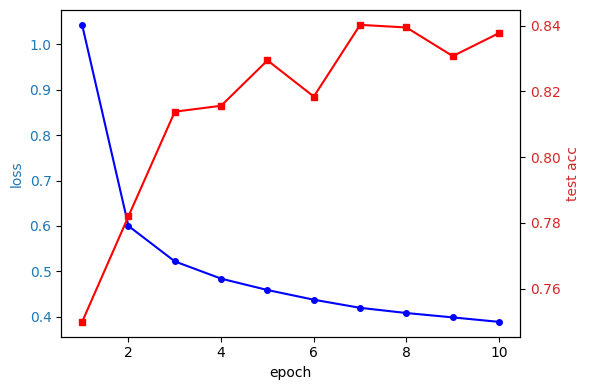

最终测试准确率: 0.838


In [15]:
# 绘制训练曲线
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss', color='tab:blue')
ax1.plot(range(1, num_epochs + 1), train_losses, 'b-o', markersize=4)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('test acc', color='tab:red')
ax2.plot(range(1, num_epochs + 1), test_accs, 'r-s', markersize=4)
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.show()

print(f'最终测试准确率: {test_accs[-1]:.3f}')

为了对学习到的模型进行评估，我们将**在一些测试数据上应用这个模型**。

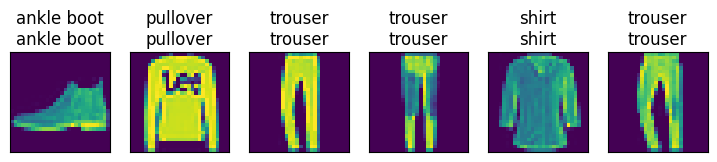

In [17]:
def get_fashion_mnist_labels(labels):
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        ax.imshow(img.numpy())
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

for X, y in test_iter:
    break
X_dev, y_dev = X.to(device), y.to(device)
trues = get_fashion_mnist_labels(y_dev.cpu())
with torch.no_grad():
    preds = get_fashion_mnist_labels(net(X_dev).argmax(dim=1).cpu())
titles = [true + '\n' + pred for true, pred in zip(trues, preds)]
show_images(X[0:6].reshape((6, 28, 28)), 1, 6, titles=titles[0:6]);

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
d2l.predict_ch3(net, test_iter)
    </pre>
  </div>
</details>


---
## 常见错误排查

| 现象 | 可能原因 | 解决方法 |
|------|---------|---------|
| pypto kernel 编译/调用失败，报 `MemCopySync failed` 或 `aicpu exception` | NPU 设备被其他进程占用 | 检查是否有残留 Python 进程占用 NPU：`ps aux \| grep python`，杀掉残留进程后重试 |
| 首次运行 pypto kernel 时报错 | 未调用 `DeviceInit()` 初始化 pypto 运行时 | 确保 env 配置 cell 已完整执行（含 `pypto.pypto_impl.DeviceInit()`），该调用必须在任何 pypto Kernel 之前 |
| 训练准确率不提升，loss 波动异常 | 张量仍留在 CPU 上，未移到 NPU | 确保数据通过 `.to(device)` 移到 NPU，参数也需一并移动（04.02 中手动 `p.data = p.data.to(device)`，04.03 中 `net.to(device)`） |
| `Reduce op: the tileShape of last axis need 32Byte align!` | pypto tile shape 末维不是 32 字节的整数倍（如 10 个 FP32 = 40 bytes） | 将 tile shape 末维改为 16 的倍数（如 `set_vec_tile_shapes(128, 16)`） |
| Kernel 首次运行等待很久（约 6 分钟） | 首次运行触发编译器 JIT 编译，正常现象 | 耐心等待，编译结果会缓存（`output/` 目录），后续 epoch 不再等待 |


## 小结

本节我们完整走通了 MLP 的从零实现全流程：
- 用 `@pypto.frontend.jit` 编写了 matmul / bias_add / ReLU 的前向与反向 Kernel
- 将 Softmax 与 CrossEntropy **解耦为 4 个独立 Kernel**，用链式法则在 `torch.autograd.Function` 中手动串联
- 用**工厂模式**将 Kernel 封装为 `torch.autograd.Function`（`ctx.save_for_backward` 是连接前向/反向的关键桥梁）
- 通过 `.apply()` 调用 NPU 算子，在 PyTorch 训练循环中完成端到端训练（最终测试准确率约 84%）

从零实现让我们看清了每个算子的内部机制，但也暴露了痛点：每新增一个算子就要写 ~20 行 Kernel + ~20 行工厂代码，模型参数也需要手动维护。下一节（[4.3 节](./04.03_mlp_concise.ipynb)）我们将用 `nn.Module` 封装这些算子——之后你就和写普通 PyTorch 代码无异了。
## 练习

1. 在所有其他参数保持不变的情况下，更改超参数`num_hiddens`的值，并查看此超参数的变化对结果有何影响。确定此超参数的最佳值。
1. 尝试添加更多的隐藏层，并查看它对结果有何影响。
1. 改变学习速率会如何影响结果？保持模型架构和其他超参数（包括轮数）不变，学习率设置为多少会带来最好的结果？
1. 通过对所有超参数（学习率、轮数、隐藏层数、每层的隐藏单元数）进行联合优化，可以得到的最佳结果是什么？
1. 描述为什么涉及多个超参数更具挑战性。
1. 如果想要构建多个超参数的搜索方法，请想出一个聪明的策略。
